Images: 200 cats: 100 dogs: 100
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Device: cuda stages: ['stem', 's1.b1', 's1.b2', 's2.b1', 's2.b2', 's3.b1', 's3.b2', 's4.b1', 's4.b2'] shapes: [(200, 64), (200, 64), (200, 64), (200, 128), (200, 128), (200, 256), (200, 256), (200, 512), (200, 512)]


,depth,stage,k,LLE,shuffle_mean,shuffle_sd,order_vs_shuffle,fraction_H_ge_0_8
0,0,stem,4,0.777,0.783,0.028,0.007,0.865
1,0,stem,8,0.897,0.907,0.020,0.011,0.910
2,0,stem,16,0.944,0.959,0.010,0.015,0.945
3,0,stem,32,0.970,0.981,0.006,0.011,1.000
4,0,stem,64,0.989,0.993,0.003,0.004,1.000
5,1,s1.b1,4,0.752,0.785,0.030,0.042,0.850
6,1,s1.b1,8,0.882,0.905,0.016,0.026,0.925
7,1,s1.b1,16,0.936,0.956,0.010,0.020,0.950
8,1,s1.b1,32,0.969,0.979,0.007,0.011,1.000
9,1,s1.b1,64,0.986,0.992,0.003,0.007,1.000


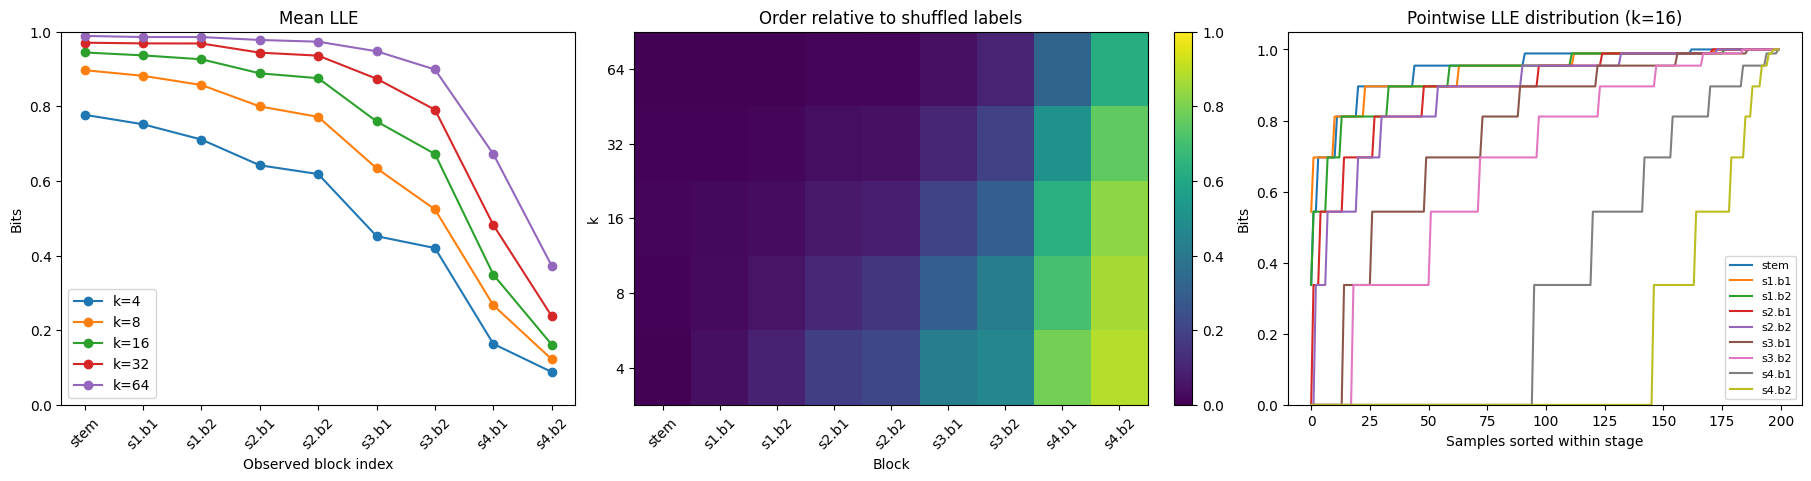

Saved CSV files in this runtime. High LLE can also occur near an organized class boundary.


In [1]:
# LLE pilot: exactly the prior experiment's Zenodo cat/dog archive, seed and 100/class sample.
# Pretrained ResNet-18, stem + 8 residual blocks, global spatial mean; cosine kNN.
from pathlib import Path
from io import BytesIO
import urllib.request, hashlib, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import models
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import entropy
from IPython.display import display
SEED=42; N_PER_CLASS=100; KS=[4,8,16,32,64]; N_SHUFFLES=100
rng=np.random.default_rng(SEED); torch.manual_seed(SEED)
archive=Path('cats_dogs_light.zip')
if not archive.exists():
    urllib.request.urlretrieve('https://zenodo.org/records/5226945/files/cats_dogs_light.zip?download=1',archive)
assert hashlib.md5(archive.read_bytes()).hexdigest()=='5e014163374c3bf7069c923de2d619c8'
transform=models.ResNet18_Weights.IMAGENET1K_V1.transforms()
class ZipCatsDogs(Dataset):
    def __init__(self,path,transform):
        self.path,self.transform=path,transform
        with zipfile.ZipFile(path) as zf:
            self.names=[n for n in zf.namelist() if '/test/' in n.lower()
                and n.lower().endswith(('.jpg','.jpeg','.png'))
                and Path(n).name.lower().startswith(('cat.','dog.'))]
        self.targets=[3 if Path(n).name.lower().startswith('cat.') else 5 for n in self.names]
    def __len__(self):return len(self.names)
    def __getitem__(self,i):
        with zipfile.ZipFile(self.path) as zf:
            img=Image.open(BytesIO(zf.read(self.names[i]))).convert('RGB')
        return self.transform(img),self.targets[i]
raw=ZipCatsDogs(archive,transform)
y_all=np.asarray(raw.targets)
indices=np.concatenate([rng.choice(np.flatnonzero(y_all==c),N_PER_CLASS,replace=False) for c in (3,5)])
indices=rng.permutation(indices).tolist()
y=y_all[indices]
assert len(y)==200 and (y==3).sum()==(y==5).sum()==100
loader=DataLoader(Subset(raw,indices),batch_size=32,shuffle=False,num_workers=0)
print('Images:',len(y),'cats:',(y==3).sum(),'dogs:',(y==5).sum())
device='cuda' if torch.cuda.is_available() else 'cpu'
model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).eval().to(device)
pairs=[('stem',model.maxpool)]
for s in range(1,5):
    for j,block in enumerate(getattr(model,f'layer{s}')):
        pairs.append((f's{s}.b{j+1}',block))
features={name:[] for name,_ in pairs}; cache={}; handles=[]
for name,module in pairs:
    def grab(_m,_inp,out,key=name):
        z=out.detach().float()
        if z.ndim==4:z=z.mean((-2,-1))
        cache[key]=z.flatten(1).cpu().numpy()
    handles.append(module.register_forward_hook(grab))
with torch.inference_mode():
    for x,_ in loader:
        model(x.to(device))
        for name in features:features[name].append(cache.pop(name))
for h in handles:h.remove()
features={name:np.concatenate(parts) for name,parts in features.items()}
print('Device:',device,'stages:',list(features),'shapes:',[v.shape for v in features.values()])

def point_lle(neighbors,labels,k):
    p=(labels[neighbors[:,:k]]==5).mean(1)
    return entropy(np.stack([1-p,p],axis=1),base=2,axis=1)
rows=[]; point_rows=[]
for depth,(stage,z) in enumerate(features.items()):
    d=cosine_distances(z); np.fill_diagonal(d,np.inf)
    nn=np.argsort(d,axis=1,kind='stable')[:,:max(KS)]
    for k in KS:
        h=point_lle(nn,y,k)
        null=np.array([point_lle(nn,rng.permutation(y),k).mean() for _ in range(N_SHUFFLES)])
        rows.append(dict(depth=depth,stage=stage,k=k,LLE=h.mean(),shuffle_mean=null.mean(),
            shuffle_sd=null.std(ddof=1),order_vs_shuffle=1-h.mean()/null.mean(),
            fraction_H_ge_0_8=(h>=.8).mean()))
        point_rows.extend(dict(depth=depth,stage=stage,k=k,image_path=raw.names[indices[i]],
            label='cat' if y[i]==3 else 'dog',H=float(h[i])) for i in range(len(y)))
summary=pd.DataFrame(rows); points=pd.DataFrame(point_rows)
display(summary.round(3))
fig,ax=plt.subplots(1,3,figsize=(18,4.7),constrained_layout=True)
for k in KS:
    sub=summary[summary.k==k]
    ax[0].plot(sub.depth,sub.LLE,'o-',label=f'k={k}')
ax[0].set(title='Mean LLE',xlabel='Observed block index',ylabel='Bits',xticks=range(len(pairs)),
          xticklabels=list(features),ylim=(0,1)); ax[0].tick_params(axis='x',rotation=45);ax[0].legend()
heat=summary.pivot(index='k',columns='depth',values='order_vs_shuffle').reindex(index=KS)
im=ax[1].imshow(heat,origin='lower',aspect='auto',vmin=0,vmax=1)
ax[1].set(title='Order relative to shuffled labels',xticks=range(len(pairs)),
          xticklabels=list(features),yticks=range(len(KS)),yticklabels=KS,xlabel='Block',ylabel='k')
ax[1].tick_params(axis='x',rotation=45);fig.colorbar(im,ax=ax[1])
for stage in features:
    ax[2].plot(sorted(points[(points.stage==stage)&(points.k==16)].H),label=stage)
ax[2].set(title='Pointwise LLE distribution (k=16)',xlabel='Samples sorted within stage',
          ylabel='Bits',ylim=(0,1.05));ax[2].legend(fontsize=8)
plt.show()
summary.to_csv('lle_summary_resnet18.csv',index=False)
points.to_csv('lle_per_image_resnet18.csv',index=False)
print('Saved CSV files in this runtime. High LLE can also occur near an organized class boundary.')

,stage,depth,n_high,high_frac,oof_accuracy,spearman_H_abs_margin,auc_near_predicts_high,near_high_rate,far_high_rate,median_abs_margin_high,median_abs_margin_low,high_misclassified
0,stem,0,189,0.945,0.580,-0.151,0.787,1.00,0.927,0.282,0.500,0.434
1,s1.b1,1,190,0.950,0.645,-0.188,0.786,1.00,0.933,0.368,0.753,0.368
2,s1.b2,2,187,0.935,0.670,-0.144,0.769,0.96,0.927,0.333,0.729,0.348
3,s2.b1,3,173,0.865,0.740,-0.331,0.731,0.94,0.840,0.600,1.009,0.283
4,s2.b2,4,170,0.850,0.790,-0.448,0.733,0.94,0.820,0.754,1.440,0.241
5,s3.b1,5,127,0.635,0.910,-0.421,0.716,0.88,0.553,1.277,2.225,0.134
6,s3.b2,6,103,0.515,0.935,-0.548,0.803,0.86,0.400,1.478,2.786,0.126
7,s4.b1,7,46,0.230,0.960,-0.675,0.863,0.66,0.087,1.971,4.987,0.130
8,s4.b2,8,15,0.075,0.990,-0.611,0.954,0.30,0.000,2.275,6.405,0.133


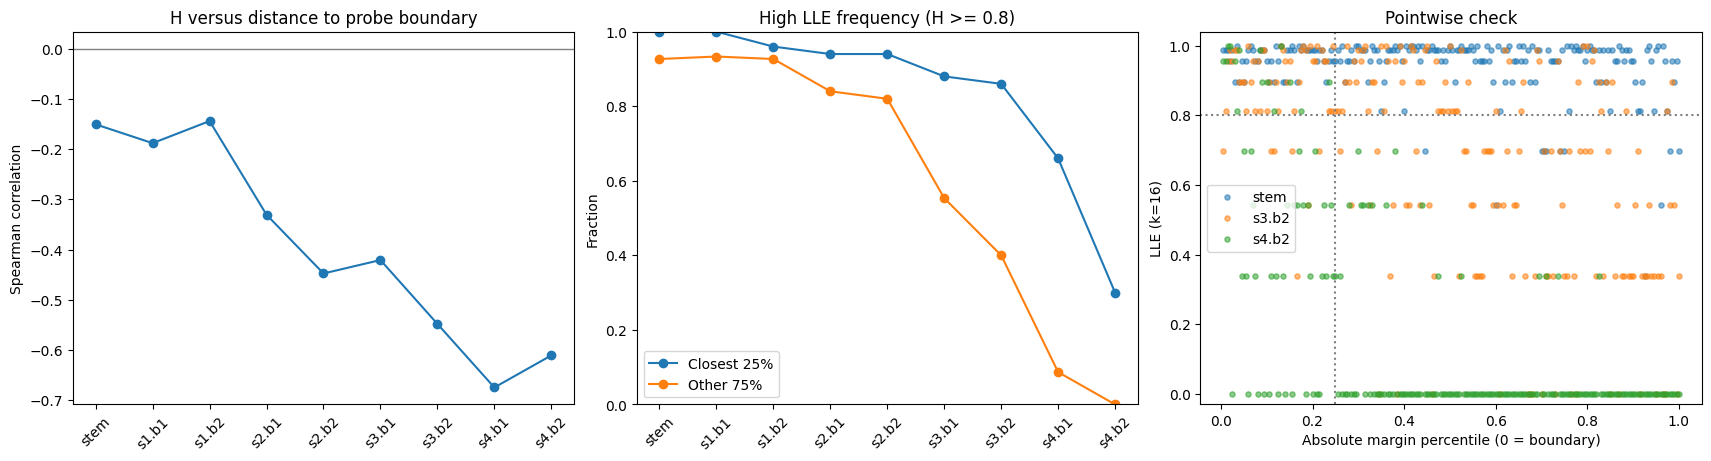

Boundary = held-out linear probe hyperplane. High LLE can also be a confidently misclassified island; inspect both margin and correctness.


In [2]:
# Are high-LLE points close to an independently fitted linear class boundary?
# Held-out signed margins from 5-fold linear probes; no sample is scored by its own training fit.
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
K=16; THRESHOLD=.8
folds=list(StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED).split(np.zeros(len(y)),y))
records=[]; per_sample=[]
for depth,(stage,z) in enumerate(features.items()):
    oof_margin=np.empty(len(y)); oof_correct=np.empty(len(y),dtype=bool)
    for train,test in folds:
        pipe=make_pipeline(Normalizer(),StandardScaler(),
            LogisticRegression(C=1,solver='liblinear',max_iter=2000,random_state=SEED))
        pipe.fit(z[train],y[train])
        # Distance in each fold's standardized feature coordinates.
        scaled=pipe[:-1].transform(z[test])
        clf=pipe[-1]
        score=clf.decision_function(scaled)
        oof_margin[test]=score/np.linalg.norm(clf.coef_)
        oof_correct[test]=(clf.predict(scaled)==y[test])
    h=points[(points.stage==stage)&(points.k==K)].H.to_numpy()
    assert len(h)==len(y) # points retain the original image order
    high=h>=THRESHOLD
    absm=np.abs(oof_margin)
    # Within-layer margin percentile makes the near-boundary quartile comparable across layers.
    near=absm<=np.quantile(absm,.25)
    spearman=spearmanr(h,absm).statistic
    auc=roc_auc_score(high,-absm) if high.any() and (~high).any() else np.nan
    records.append(dict(stage=stage,depth=depth,n_high=int(high.sum()),
        high_frac=high.mean(),oof_accuracy=oof_correct.mean(),
        spearman_H_abs_margin=spearman,auc_near_predicts_high=auc,
        near_high_rate=high[near].mean(),far_high_rate=high[~near].mean(),
        median_abs_margin_high=np.median(absm[high]) if high.any() else np.nan,
        median_abs_margin_low=np.median(absm[~high]) if (~high).any() else np.nan,
        high_misclassified=(~oof_correct[high]).mean() if high.any() else np.nan))
    per_sample.extend(dict(stage=stage,depth=depth,image_path=raw.names[indices[i]],
        label='cat' if y[i]==3 else 'dog',H=h[i],abs_margin=absm[i],
        margin_percentile=(absm<=absm[i]).mean(),near=near[i],
        high_entropy=high[i],correct=oof_correct[i]) for i in range(len(y)))
boundary=pd.DataFrame(records); boundary_points=pd.DataFrame(per_sample)
display(boundary.round(3))
fig,ax=plt.subplots(1,3,figsize=(17,4.5),constrained_layout=True)
ax[0].plot(boundary.depth,boundary.spearman_H_abs_margin,'o-')
ax[0].axhline(0,color='gray',lw=1)
ax[0].set(title='H versus distance to probe boundary',ylabel='Spearman correlation',
          xticks=boundary.depth,xticklabels=boundary.stage)
ax[1].plot(boundary.depth,boundary.near_high_rate,'o-',label='Closest 25%')
ax[1].plot(boundary.depth,boundary.far_high_rate,'o-',label='Other 75%')
ax[1].set(title='High LLE frequency (H >= 0.8)',ylabel='Fraction',
          xticks=boundary.depth,xticklabels=boundary.stage,ylim=(0,1));ax[1].legend()
for stage,color in [('stem','gray'),('s3.b2','orange'),('s4.b2','purple')]:
    q=boundary_points[boundary_points.stage==stage]
    ax[2].scatter(q.margin_percentile,q.H,s=14,alpha=.55,label=stage)
ax[2].axvline(.25,color='gray',ls=':');ax[2].axhline(.8,color='gray',ls=':')
ax[2].set(title='Pointwise check',xlabel='Absolute margin percentile (0 = boundary)',
          ylabel='LLE (k=16)',ylim=(-.03,1.04));ax[2].legend()
for a in ax[:2]:a.tick_params(axis='x',rotation=45)
plt.show()
boundary.to_csv('lle_boundary_summary.csv',index=False)
boundary_points.to_csv('lle_boundary_per_image.csv',index=False)
print('Boundary = held-out linear probe hyperplane. High LLE can also be a confidently misclassified island; inspect both margin and correctness.')

In [3]:
# Sensitivity to k and exact enrichment of high-LLE points near the final-layer probe boundary.
from scipy.stats import hypergeom
checks=[]
for stage in ['s3.b2','s4.b1','s4.b2']:
    b=boundary_points[boundary_points.stage==stage].reset_index(drop=True)
    for k in [4,8,16,32,64]:
        h=points[(points.stage==stage)&(points.k==k)].H.to_numpy()
        high=h>=.8; near=b.near.to_numpy()
        count=(high&near).sum(); total=high.sum()
        checks.append(dict(stage=stage,k=k,n_high=int(total),n_high_in_nearest_25pct=int(count),
            fraction_high_near=count/total if total else np.nan,
            spearman_H_abs_margin=spearmanr(h,b.abs_margin).statistic,
            hypergeom_p=hypergeom.sf(count-1,len(y),near.sum(),total) if total else np.nan))
robustness=pd.DataFrame(checks)
display(robustness.round(4))
robustness.to_csv('lle_boundary_k_sensitivity.csv',index=False)

,stage,k,n_high,n_high_in_nearest_25pct,fraction_high_near,spearman_H_abs_margin,hypergeom_p
0,s3.b2,4,98,39,0.3980,-0.4703,0.0
1,s3.b2,8,91,36,0.3956,-0.5111,0.0
2,s3.b2,16,103,43,0.4175,-0.5480,0.0
3,s3.b2,32,120,47,0.3917,-0.5253,0.0
4,s3.b2,64,168,50,0.2976,-0.4295,0.0
5,s4.b1,4,37,26,0.7027,-0.4908,0.0
6,s4.b1,8,39,31,0.7949,-0.5941,0.0
7,s4.b1,16,46,33,0.7174,-0.6746,0.0
8,s4.b1,32,53,36,0.6792,-0.7120,0.0
9,s4.b1,64,85,44,0.5176,-0.7165,0.0


## Cross-model local label entropy
Run the original ResNet-18 cell first, then the two cells below. They reuse the exact 100 cat + 100 dog sample identities, their order, spatial mean pooling, cosine distance, self exclusion and k = 4, 8, 16, 32, 64. Added models: ResNet-152 (stem + 50 residual blocks), ConvNeXt-Tiny (stem + 18 blocks + 3 downsampling observations), ConvNeXt-Base (stem + 36 blocks + 3 downsampling observations).

ResNet-152 uses explicit ImageNet-1K V2 weights. ResNet-18, ConvNeXt-Tiny and ConvNeXt-Base retain their original ImageNet-1K V1 weights. All models retain the original ResNet-18 preprocessing to control input differences. Shared label permutations provide matched random-label baselines. Original ResNet-18 results and probe analyses above are preserved. The new section computes LLE only; it does not add linear probes or claim boundary localization for the new models.

Outputs include per-image LLE, per-layer summaries, pooled vectors, sample manifest, protocol, curves and heatmaps in `lle_cross_model/`. Relative depth is normalized observation index, not matched semantic or computational depth. LLE measures local label mixing; declines need not be monotonic and do not imply decreasing entropy of the vectors themselves. Permutation SD describes the null spread, not a confidence interval for dataset generalization.

**Execution status:** the uploaded Colab rerun completed all code cells on CUDA. ResNet-152 used ImageNet-1K V2 weights (`resnet152-f82ba261.pth`); ResNet-18 and ConvNeXt-Tiny/Base retain V1 weights. All models use the same 200-image cohort, shared ResNet-18 V1 preprocessing, spatial mean pooling and cosine kNN with k = 4, 8, 16, 32, 64. The notebook includes completed layer tables, endpoint summaries and comparison plots, with no saved error outputs. At k=16, ResNet-152 mean LLE changes from 0.9437 to 0.1074 across 51 observations, with 10 increasing transitions. This is an overall reduction in local label mixing, not strict monotonicity; neighborhoods are recomputed at each observation. Boundary localization was tested only for ResNet-18. Separate runtime CSV/NPZ files are not bundled in this notebook.


In [4]:
# Cross-model LLE: run the original first cell before this cell.
# Reuses exact image identities, labels, preprocessing and cosine definition.
import gc, json, hashlib
from collections import OrderedDict
from tqdm.auto import tqdm
assert all(name in globals() for name in ('raw','indices','y','KS','point_lle','summary','points'))
assert len(indices)==len(y)==200 and len(set(indices))==200
CROSS_DIR=Path('lle_cross_model'); CROSS_DIR.mkdir(exist_ok=True)
manifest=[dict(image_path=raw.names[i],label=int(label)) for i,label in zip(indices,y)]
(CROSS_DIR/'sample_manifest.json').write_text(json.dumps(manifest,indent=2))
# Fixed ResNet-18 transform is intentionally used for all models for controlled comparison.
# Weight enums are explicit: no moving DEFAULT alias.
CONFIGS=[('resnet152',models.resnet152,models.ResNet152_Weights.IMAGENET1K_V2),
         ('convnext_tiny',models.convnext_tiny,models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1),
         ('convnext_base',models.convnext_base,models.ConvNeXt_Base_Weights.IMAGENET1K_V1)]
# Use the same shuffled assignments at every layer/model/k.
null_rng=np.random.default_rng(SEED+1000)
shuffled_labels=np.stack([null_rng.permutation(y) for _ in range(N_SHUFFLES)])
# Preserve original ResNet-18 outputs; added baselines below use shared permutations.
cross_summaries=[summary.assign(model='resnet18')]
cross_points=[points.assign(model='resnet18')]
model_metadata=[]
if 'model' in globals():
    model.to('cpu') # release GPU occupied by the existing ResNet-18
if torch.cuda.is_available(): torch.cuda.empty_cache()

def observation_modules(net,name):
    observations=OrderedDict()
    if name.startswith('resnet'):
        observations['stem']=net.maxpool
        for s in range(1,5):
            for j,block in enumerate(getattr(net,f'layer{s}')):
                observations[f's{s}.b{j+1}']=block
    else:
        observations['stem']=net.features[0]
        for s,feature_index in enumerate((1,3,5,7),start=1):
            if s>1: observations[f'down{s-1}']=net.features[feature_index-1]
            for j,block in enumerate(net.features[feature_index]):
                observations[f's{s}.b{j+1}']=block
    return observations

def extract_cross_features(net,observations):
    chunks={name:[] for name in observations}; batch_cache={}; hooks=[]
    def hook(key):
        def capture(_module,_inputs,out):
            z=out.detach().float()
            if z.ndim==4: z=z.mean(dim=(-2,-1))
            batch_cache[key]=z.flatten(1).cpu().numpy()
        return capture
    try:
        for name,module in observations.items(): hooks.append(module.register_forward_hook(hook(name)))
        # Smaller batches keep ConvNeXt-Base memory use bounded.
        cross_loader=DataLoader(Subset(raw,indices),batch_size=8,shuffle=False,num_workers=0)
        seen=[]
        with torch.inference_mode():
            for x,labels in tqdm(cross_loader,desc='Extracting pooled vectors'):
                batch_cache.clear(); net(x.to(device))
                seen.extend(labels.numpy().tolist())
                for name in chunks: chunks[name].append(batch_cache[name])
        assert np.array_equal(np.asarray(seen),y)
        return OrderedDict((name,np.concatenate(parts)) for name,parts in chunks.items())
    finally:
        for handle in hooks: handle.remove()

def analyze_cross(z_by_layer,model_name):
    records=[]; point_records=[]
    for depth,(stage,z) in enumerate(tqdm(z_by_layer.items(),desc='Cosine kNN LLE')):
        assert z.shape[0]==len(y) and np.isfinite(z).all()
        distances=cosine_distances(z); np.fill_diagonal(distances,np.inf)
        neighbors=np.argsort(distances,axis=1,kind='stable')[:,:max(KS)]
        assert not np.any(neighbors==np.arange(len(y))[:,None])
        for k in KS:
            h=point_lle(neighbors,y,k)
            null=np.array([point_lle(neighbors,labels,k).mean() for labels in shuffled_labels])
            records.append(dict(model=model_name,depth=depth,stage=stage,k=k,LLE=float(h.mean()),
                shuffle_mean=float(null.mean()),shuffle_sd=float(null.std(ddof=1)),
                order_vs_shuffle=float(1-h.mean()/null.mean()),fraction_H_ge_0_8=float((h>=.8).mean())))
            point_records.extend(dict(model=model_name,depth=depth,stage=stage,k=k,
                image_path=manifest[i]['image_path'],label='cat' if y[i]==3 else 'dog',H=float(h[i]))
                for i in range(len(y)))
    return pd.DataFrame(records),pd.DataFrame(point_records)

for model_name,constructor,weights in CONFIGS:
    print('Running',model_name,'on',device,flush=True)
    net=constructor(weights=weights).eval().to(device)
    try:
        observations=observation_modules(net,model_name)
        z_by_layer=extract_cross_features(net,observations)
    finally:
        net.to('cpu'); del net; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    np.savez_compressed(CROSS_DIR/f'{model_name}_pooled_vectors.npz',**z_by_layer)
    result,point_result=analyze_cross(z_by_layer,model_name)
    result.to_csv(CROSS_DIR/f'lle_summary_{model_name}.csv',index=False)
    point_result.to_csv(CROSS_DIR/f'lle_per_image_{model_name}.csv',index=False)
    cross_summaries.append(result); cross_points.append(point_result)
    model_metadata.append(dict(model=model_name,weights=str(weights),stages=list(z_by_layer),
        shapes={key:list(z.shape) for key,z in z_by_layer.items()}))
    display(result[result.k==16].round(4))
    del z_by_layer; gc.collect()
# Recalculate ResNet-18 shuffled baselines with the same assignments for comparison.
matched_resnet18,_=analyze_cross(features,'resnet18')
cross_summaries[0]=matched_resnet18
cross_summary=pd.concat(cross_summaries,ignore_index=True)
cross_pointwise=pd.concat(cross_points,ignore_index=True)
cross_summary['relative_depth']=cross_summary.groupby('model')['depth'].transform(
    lambda d:d/d.max() if d.max()>0 else d*0)
cross_summary.to_csv(CROSS_DIR/'lle_summary_all_models.csv',index=False)
cross_pointwise.to_csv(CROSS_DIR/'lle_per_image_all_models.csv',index=False)
(CROSS_DIR/'protocol.json').write_text(json.dumps(dict(seed=SEED,k_values=KS,
    n_shuffles=N_SHUFFLES,metric='cosine',pooling='spatial mean',
    preprocessing='shared ResNet18 IMAGENET1K_V1 transform',models=model_metadata),indent=2))
print('Completed all three additional models. Outputs:',CROSS_DIR.resolve())


Running resnet152 on cuda
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 203MB/s]


Extracting pooled vectors:   0%|          | 0/25 [00:00<?, ?it/s]

Cosine kNN LLE:   0%|          | 0/51 [00:00<?, ?it/s]

,model,depth,stage,k,LLE,shuffle_mean,shuffle_sd,order_vs_shuffle,fraction_H_ge_0_8
2,resnet152,0,stem,16,0.9437,0.9561,0.0122,0.0130,0.940
7,resnet152,1,s1.b1,16,0.9431,0.9573,0.0099,0.0149,0.960
12,resnet152,2,s1.b2,16,0.9413,0.9576,0.0100,0.0171,0.965
17,resnet152,3,s1.b3,16,0.9377,0.9579,0.0097,0.0210,0.965
22,resnet152,4,s2.b1,16,0.9243,0.9584,0.0100,0.0356,0.945
27,resnet152,5,s2.b2,16,0.9283,0.9577,0.0104,0.0307,0.945
32,resnet152,6,s2.b3,16,0.9074,0.9580,0.0110,0.0528,0.910
37,resnet152,7,s2.b4,16,0.9041,0.9579,0.0107,0.0562,0.905
42,resnet152,8,s2.b5,16,0.8988,0.9577,0.0105,0.0615,0.895
47,resnet152,9,s2.b6,16,0.8959,0.9578,0.0103,0.0646,0.890


...

Extracting pooled vectors:   0%|          | 0/25 [00:00<?, ?it/s]

Cosine kNN LLE:   0%|          | 0/40 [00:00<?, ?it/s]

,model,depth,stage,k,LLE,shuffle_mean,shuffle_sd,order_vs_shuffle,fraction_H_ge_0_8
2,convnext_base,0,stem,16,0.9164,0.9579,0.0112,0.0433,0.925
7,convnext_base,1,s1.b1,16,0.9350,0.9583,0.0099,0.0243,0.960
12,convnext_base,2,s1.b2,16,0.9394,0.9584,0.0092,0.0198,0.945
17,convnext_base,3,s1.b3,16,0.9428,0.9569,0.0092,0.0148,0.950
22,convnext_base,4,down1,16,0.9437,0.9570,0.0089,0.0139,0.965
27,convnext_base,5,s2.b1,16,0.9348,0.9572,0.0091,0.0234,0.965
32,convnext_base,6,s2.b2,16,0.8847,0.9570,0.0101,0.0755,0.855
37,convnext_base,7,s2.b3,16,0.8257,0.9571,0.0100,0.1373,0.755
42,convnext_base,8,down2,16,0.8710,0.9566,0.0085,0.0895,0.810
47,convnext_base,9,s3.b1,16,0.8664,0.9565,0.0091,0.0942,0.805


Cosine kNN LLE:   0%|          | 0/9 [00:00<?, ?it/s]

Completed all three additional models. Outputs: /content/lle_cross_model


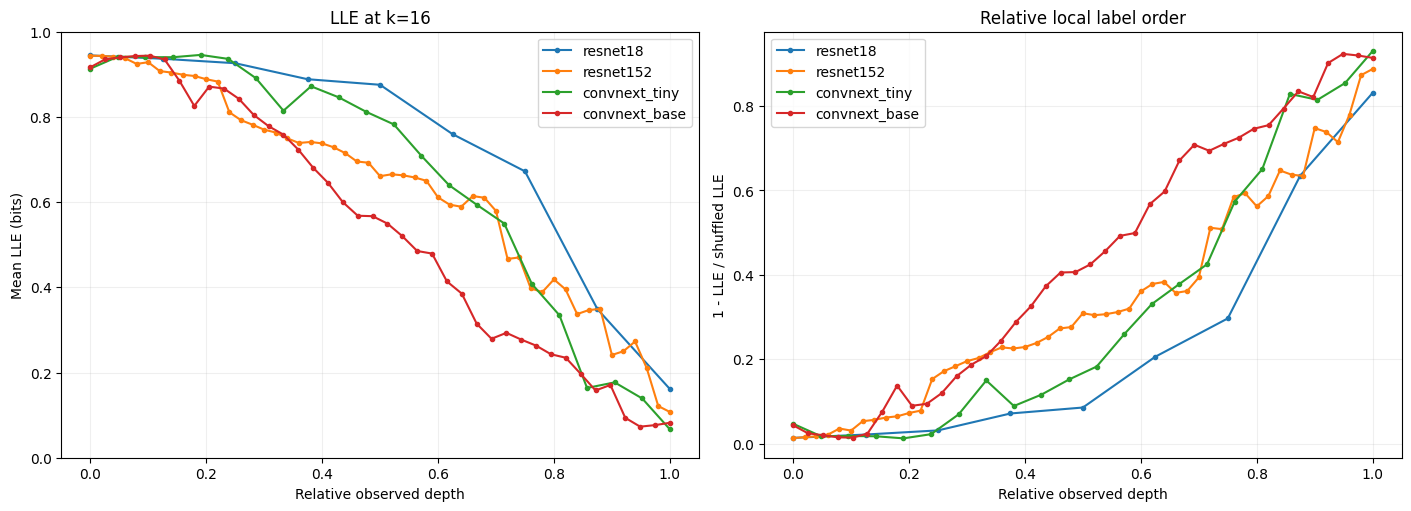

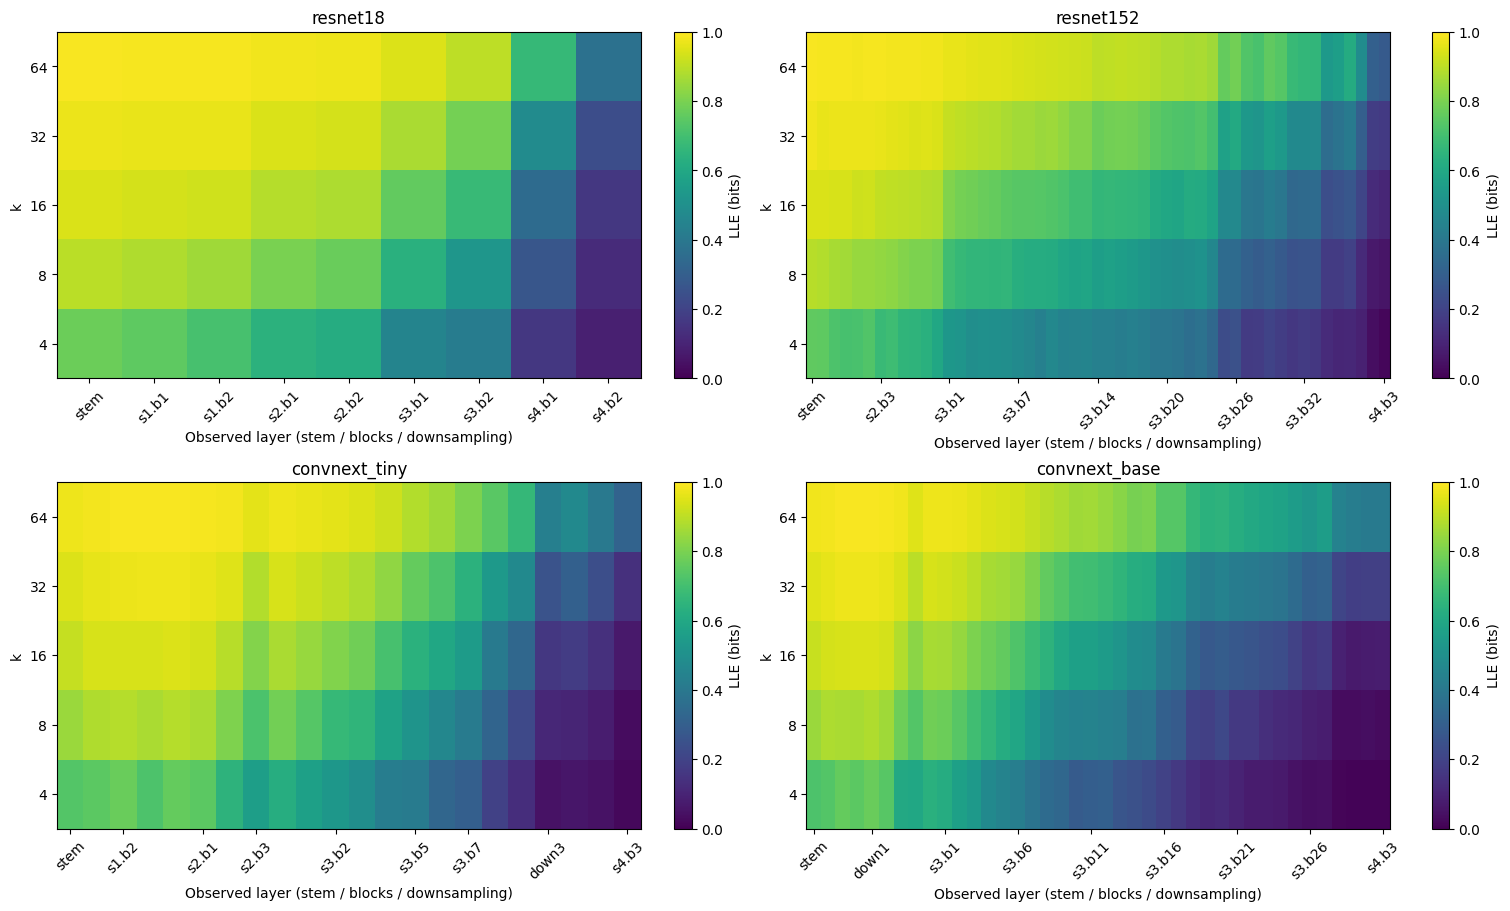

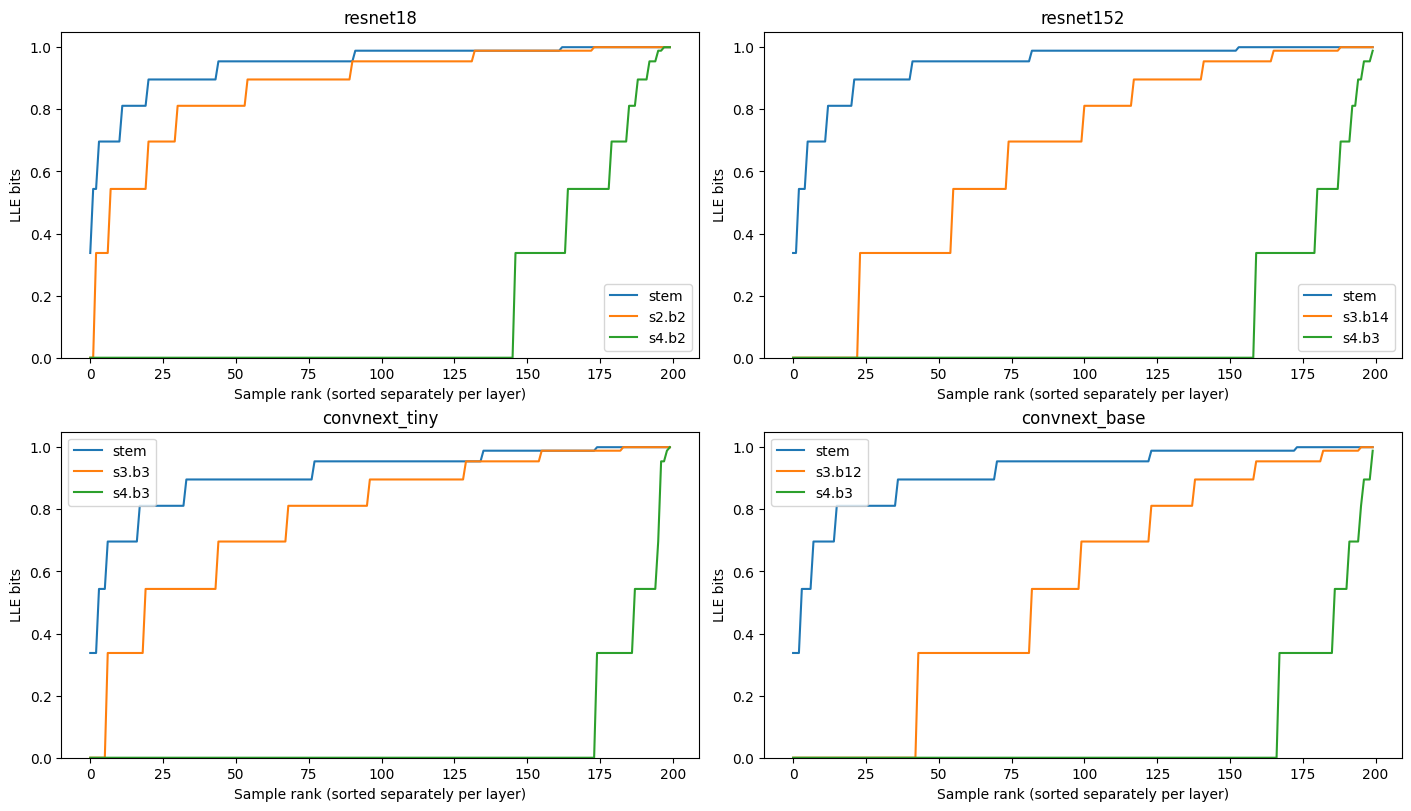

,model,k,n_observations,initial_LLE,final_LLE,net_drop,n_increasing_transitions
0,resnet18,4,9,0.7772,0.0880,0.6892,0
1,resnet18,8,9,0.8968,0.1221,0.7748,0
2,resnet18,16,9,0.9443,0.1613,0.7830,0
3,resnet18,32,9,0.9704,0.2374,0.7330,0
4,resnet18,64,9,0.9886,0.3722,0.6165,0
5,resnet152,4,51,0.7554,0.0172,0.7382,14
6,resnet152,8,51,0.8915,0.0577,0.8338,11
7,resnet152,16,51,0.9437,0.1074,0.8362,10
8,resnet152,32,51,0.9791,0.1692,0.8099,13
9,resnet152,64,51,0.9910,0.2824,0.7086,10


Relative depth compares observation order, not equal computational depth. Inspect stage names for transitions.


In [5]:
# Cross-model curves, LLE spectrum and pointwise distributions.
model_order=['resnet18','resnet152','convnext_tiny','convnext_base']
fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
for model_name in model_order:
    q=cross_summary[(cross_summary.model==model_name)&(cross_summary.k==16)].sort_values('depth')
    axes[0].plot(q.relative_depth,q.LLE,'o-',markersize=3,label=model_name)
    axes[1].plot(q.relative_depth,q.order_vs_shuffle,'o-',markersize=3,label=model_name)
axes[0].set(xlabel='Relative observed depth',ylabel='Mean LLE (bits)',title='LLE at k=16',ylim=(0,1))
axes[1].set(xlabel='Relative observed depth',ylabel='1 - LLE / shuffled LLE',title='Relative local label order')
for a in axes: a.legend(); a.grid(alpha=.2)
fig.savefig(CROSS_DIR/'cross_model_k16.png',dpi=180); plt.show()
fig,axes=plt.subplots(2,2,figsize=(15,9),constrained_layout=True)
for model_name,a in zip(model_order,axes.flat):
    q=cross_summary[cross_summary.model==model_name]
    heat=q.pivot(index='k',columns='depth',values='LLE').reindex(index=KS)
    im=a.imshow(heat,origin='lower',aspect='auto',vmin=0,vmax=1,cmap='viridis')
    stage_names=q.drop_duplicates('depth').sort_values('depth').stage.tolist()
    ticks=np.unique(np.linspace(0,len(stage_names)-1,min(9,len(stage_names))).astype(int))
    a.set(title=model_name,xlabel='Observed layer (stem / blocks / downsampling)',ylabel='k',
          xticks=ticks,xticklabels=[stage_names[i] for i in ticks],
          yticks=range(len(KS)),yticklabels=KS)
    a.tick_params(axis='x',rotation=45); fig.colorbar(im,ax=a,label='LLE (bits)')
fig.savefig(CROSS_DIR/'lle_spectrum_all_models.png',dpi=180); plt.show()
fig,axes=plt.subplots(2,2,figsize=(14,8),constrained_layout=True)
for model_name,a in zip(model_order,axes.flat):
    q=cross_summary[cross_summary.model==model_name]
    stages=q.drop_duplicates('depth').sort_values('depth').stage.tolist()
    for j in np.unique([0,len(stages)//2,len(stages)-1]):
        h=cross_pointwise[(cross_pointwise.model==model_name)&(cross_pointwise.stage==stages[j])&
                         (cross_pointwise.k==16)].H.to_numpy()
        a.plot(np.sort(h),label=stages[j])
    a.set(title=model_name,xlabel='Sample rank (sorted separately per layer)',ylabel='LLE bits',ylim=(0,1.05))
    a.legend()
fig.savefig(CROSS_DIR/'pointwise_lle_all_models.png',dpi=180); plt.show()
endpoint_rows=[]
for model_name in model_order:
    for k in KS:
        q=cross_summary[(cross_summary.model==model_name)&(cross_summary.k==k)].sort_values('depth')
        endpoint_rows.append(dict(model=model_name,k=k,n_observations=len(q),
            initial_LLE=q.LLE.iloc[0],final_LLE=q.LLE.iloc[-1],
            net_drop=q.LLE.iloc[0]-q.LLE.iloc[-1],
            n_increasing_transitions=int((np.diff(q.LLE)>1e-8).sum())))
endpoint_summary=pd.DataFrame(endpoint_rows)
endpoint_summary.to_csv(CROSS_DIR/'lle_endpoints.csv',index=False)
display(endpoint_summary.round(4))
print('Relative depth compares observation order, not equal computational depth. Inspect stage names for transitions.')
